In [7]:
from google.colab import files

print("Upload actuals-jan2024-clean.json")
uploaded = files.upload()

Upload actuals-jan2024-clean.json


Saving actuals-jan2024-clean.json to actuals-jan2024-clean (1).json


In [8]:
import json
import pandas as pd

with open("actuals-jan2024-clean.json") as f:
    actuals_raw = json.load(f)

actuals = pd.DataFrame(actuals_raw)

actuals["startTime"] = pd.to_datetime(actuals["startTime"])

print("Dataset shape:", actuals.shape)
print()
print(actuals.head())

Dataset shape: (1472, 2)

                  startTime  generation
0 2024-01-01 00:00:00+00:00       11713
1 2024-01-01 00:30:00+00:00       12232
2 2024-01-01 01:00:00+00:00       12702
3 2024-01-01 01:30:00+00:00       12833
4 2024-01-01 02:00:00+00:00       12849


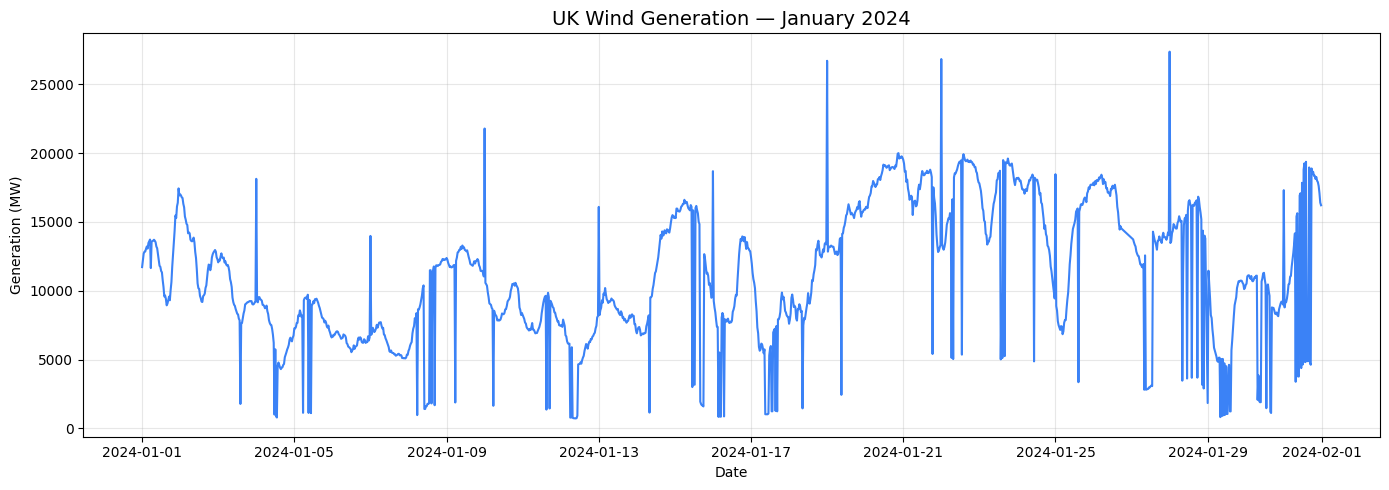

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(actuals["startTime"], actuals["generation"], color="#3b82f6")

plt.title("UK Wind Generation — January 2024", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Generation (MW)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

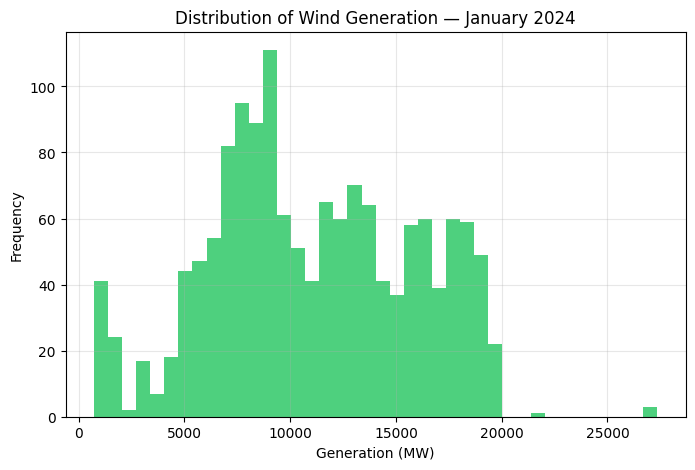

In [10]:
plt.figure(figsize=(8,5))

plt.hist(actuals["generation"], bins=40, color="#22c55e", alpha=0.8)

plt.title("Distribution of Wind Generation — January 2024")
plt.xlabel("Generation (MW)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

In [11]:
p10 = actuals["generation"].quantile(0.10)
p25 = actuals["generation"].quantile(0.25)
p50 = actuals["generation"].quantile(0.50)
p75 = actuals["generation"].quantile(0.75)
p90 = actuals["generation"].quantile(0.90)

print("Wind Generation Percentiles (MW)")
print("--------------------------------")
print("P10:", round(p10))
print("P25:", round(p25))
print("P50 (Median):", round(p50))
print("P75:", round(p75))
print("P90:", round(p90))

Wind Generation Percentiles (MW)
--------------------------------
P10: 5342
P25: 7655
P50 (Median): 10600
P75: 15078
P90: 17896


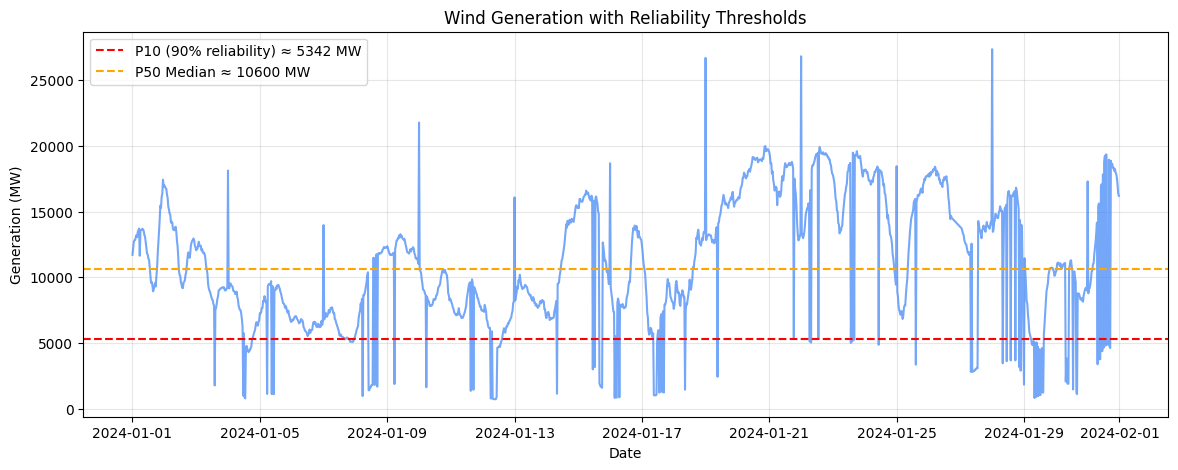

In [12]:
plt.figure(figsize=(14,5))

plt.plot(actuals["startTime"], actuals["generation"], color="#3b82f6", alpha=0.7)

plt.axhline(p10, color="red", linestyle="--", label=f"P10 (90% reliability) ≈ {round(p10)} MW")
plt.axhline(p50, color="orange", linestyle="--", label=f"P50 Median ≈ {round(p50)} MW")

plt.title("Wind Generation with Reliability Thresholds")
plt.xlabel("Date")
plt.ylabel("Generation (MW)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Reliability Recommendation

The analysis of January 2024 wind generation shows significant variability in output, ranging from low-wind periods below 5000 MW to peaks above 25000 MW.

We use the P10 percentile as a reliability benchmark because it represents a generation level exceeded 90% of the time, making it a conservative estimate for dependable wind capacity.

The P10 percentile is approximately **5342 MW**, meaning wind generation remains above this level **90% of the time**.

Therefore, approximately **5 GW of wind power can be considered reliably available** to meet electricity demand. This represents a conservative estimate of dependable wind capacity.

While the median generation is around **10.6 GW**, relying on this level would be risky because wind output frequently falls below it during low-wind periods.

Using the P10 threshold provides a practical reliability benchmark for grid planning and ensures sufficient backup capacity is maintained.